# MCP under the hood — instructor demonstration

This short notebook is for the instructor's screen only. Attendees
watch this notebook and do not run it.

## Goal

Make the protocol boundary concrete before the ADK lesson: inspect
the public server, initialize one direct Python session, and list its
advertised tools without executing any tool.

## Setup

### Use the hosted MCP client

Hosted JupyterLab already includes MCP 1.29.0 from
notebooks/requirements.txt. Continue directly to discovery.

## Steps

This lesson focuses on MCP tools. MCP servers may also advertise
resources and prompts, but those are outside today's live path.

### Instructor MCP Inspector fallback

This captured instructor view confirms the public server is connected
and advertises five tools. During the live session, the instructor uses
Inspector only for discovery; attendees do not install or run it.

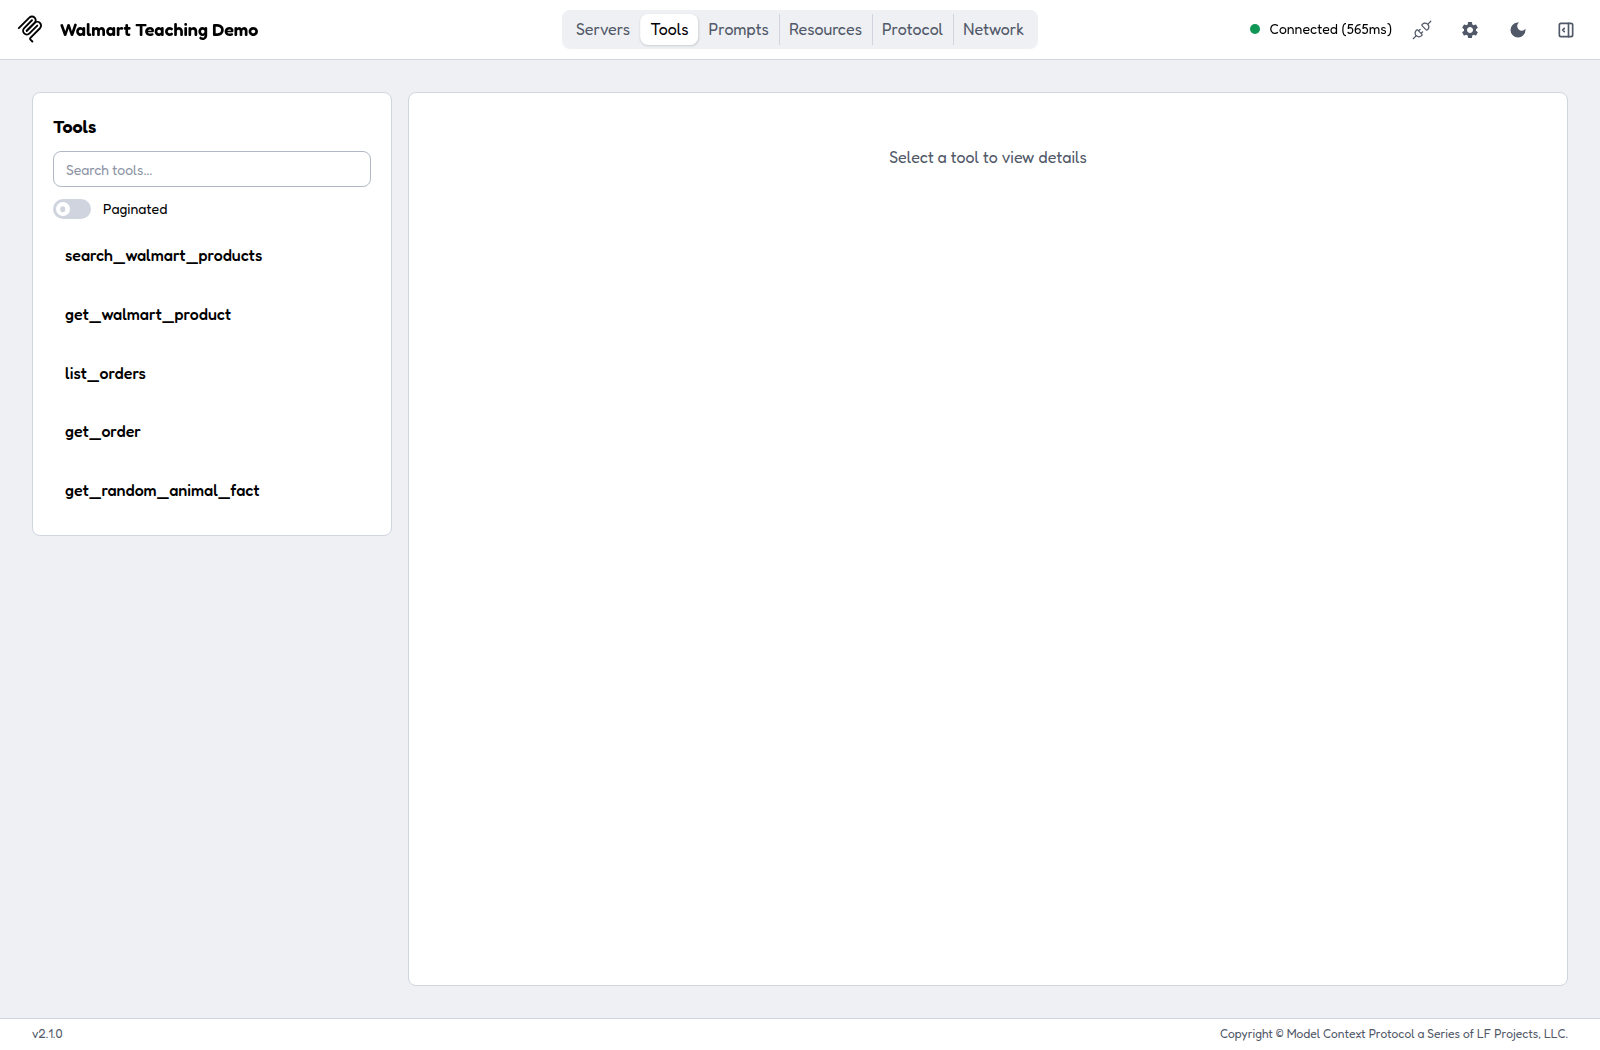

### Discover tools with the Python SDK

Open the streamable HTTP transport, initialize the session, and ask
for the tool catalog. The context managers close the connection when
discovery finishes. There is deliberately no tool call.

In [ ]:
from mcp import ClientSession
from mcp.client.streamable_http import streamable_http_client

MCP_ENDPOINT = 'https://walmart-demo-api-k2yx3oubha-ue.a.run.app/mcp'


async def discover_mcp_tools():
    async with streamable_http_client(MCP_ENDPOINT) as (
        read_stream,
        write_stream,
        _,
    ):
        async with ClientSession(read_stream, write_stream) as session:
            await session.initialize()
            result = await session.list_tools()
            return [
                {"name": tool.name, "description": tool.description or ""}
                for tool in result.tools
            ]


discovered_tools = await discover_mcp_tools()
discovered_tools

## Checks

The catalog should contain five teaching tools: two order tools, two
product tools, and one animal-fact tool. Stop here—ADK makes the first
real order-tool call in the learner notebook.

## Next Steps

Switch once to the cumulative Orders ADK notebook. From this point
forward, learners see only ADK's MCP toolset, Skill, subagent, and the
traces that compare those layers.